# Seasonal Agriculture Performance Analysis


**Objective:** Analyze agricultural data from different seasons (*Kharif, Rabi, Zaid*) to identify
meaningful patterns, trends, relationships and differences in agricultural performance, and
develop evidence-based, data-driven recommendations.

**Notebook sections**
1. Import Libraries & Load Data
2. Data Understanding
3. Data Cleaning & Preparation
4. Exploratory Data Analysis (Univariate)
5. Seasonal Performance Comparison (Bivariate)
6. Statistical Testing (ANOVA / Tukey HSD)
7. Correlation & Relationship Analysis
8. Crop-wise & Region-wise Seasonal Patterns
9. Resource Usage & Efficiency Analysis
10. Key Insights
11. Recommendations


## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display / plotting settings
pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

df = pd.read_csv('agriculture_data.csv')
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 2. Data Understanding

Explore structure, data types, summary statistics and missing values before doing any analysis.

In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [3]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF10001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,4000.0,NaN,NaN,NaN,7.888265,4.223764,0.5,4.26,7.895,11.65,15.0
Rainfall_mm,3952.0,NaN,NaN,NaN,601.152657,288.925025,80.0,370.2,582.0,834.95,1395.2
Avg_Temperature_C,4000.0,NaN,NaN,NaN,26.8189,3.81818,16.2,23.9,26.9,29.6,39.7
Humidity_pct,4000.0,NaN,NaN,NaN,63.2105,11.960834,25.0,54.775,63.0,71.9,95.0
Sunlight_Hours_Day,4000.0,NaN,NaN,NaN,7.32305,1.121186,3.5,6.6,7.3,8.1,11.0


In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df[missing_df['missing_count'] > 0]


,missing_count,missing_pct
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


In [5]:
print("Duplicate rows:", df.duplicated().sum())
print("\nUnique Seasons:", df['Season'].unique())
print("Unique States:", df['State'].nunique())
print("Unique Crops:", df['Crop'].unique())
print("Unique Irrigation Methods:", df['Irrigation_Method'].unique())


Duplicate rows: 0

Unique Seasons: <StringArray>
['Kharif', 'Rabi', 'Zaid']
Length: 3, dtype: str
Unique States: 8
Unique Crops: <StringArray>
[    'Wheat',     'Maize',    'Pulses',      'Rice',    'Cotton',    'Chilli',
 'Groundnut', 'Sugarcane']
Length: 8, dtype: str
Unique Irrigation Methods: <StringArray>
['Drip', 'Flood', 'Rainfed', 'Sprinkler']
Length: 4, dtype: str


## 3. Data Cleaning & Preparation

Missing values exist in `Rainfall_mm`, `Soil_Moisture_pct` and `Yield_Tonnes_Ha`.
Instead of a blanket fill, missing values are imputed using the **median of the same
Season + Crop group**, which preserves seasonal/crop-specific patterns better than a
single global median. We also check for outliers and negative/invalid values.

In [6]:
df_clean = df.copy()

cols_to_impute = ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']

for col in cols_to_impute:
    df_clean[col] = df_clean.groupby(['Season', 'Crop'])[col]\
                             .transform(lambda x: x.fillna(x.median()))
    # fallback: if a Season+Crop group was entirely NaN, use overall median
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Remaining missing values after imputation:")
print(df_clean[cols_to_impute].isnull().sum())


Remaining missing values after imputation:
Rainfall_mm          0
Soil_Moisture_pct    0
Yield_Tonnes_Ha      0
dtype: int64


In [7]:
# Outlier check using IQR on key performance columns
key_cols = ['Yield_Tonnes_Ha', 'Profit_INR', 'Water_Efficiency_t_per_1000m3']

for col in key_cols:
    Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    print(f"{col}: {len(outliers)} potential outliers ({len(outliers)/len(df_clean)*100:.1f}%) "
          f"| valid range approx [{lower:.1f}, {upper:.1f}]")

# Outliers are kept (agriculture data legitimately varies widely with real crop failures/
# bumper yields), but flagged for awareness. Extreme negative profits are expected since
# Total_Cost_INR can exceed Revenue_INR for a genuinely loss-making season/crop combination.


Yield_Tonnes_Ha: 304 potential outliers (7.6%) | valid range approx [-1.6, 5.5]
Profit_INR: 404 potential outliers (10.1%) | valid range approx [-696111.0, 763567.0]
Water_Efficiency_t_per_1000m3: 322 potential outliers (8.1%) | valid range approx [-3.6, 10.4]


In [8]:
# Derived / helper columns useful for the analysis
df_clean['Profit_Margin_pct'] = (df_clean['Profit_INR'] / df_clean['Revenue_INR'].replace(0, np.nan)) * 100
df_clean['Cost_per_Tonne'] = df_clean['Total_Cost_INR'] / df_clean['Production_Tonnes'].replace(0, np.nan)

season_order = ['Kharif', 'Rabi', 'Zaid']
df_clean['Season'] = pd.Categorical(df_clean['Season'], categories=season_order, ordered=True)

df_clean.to_csv('agriculture_data_cleaned.csv', index=False)
print("Cleaned dataset saved. Shape:", df_clean.shape)
df_clean.head()


Cleaned dataset saved. Shape: (4000, 30)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_Margin_pct,Cost_per_Tonne
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3,-38.468030,32816.923077
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9,-1118.660429,251199.489796
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7,-65.494104,124588.932806
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6,-47.675600,35802.415459
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3,-74.559288,36339.677419


## 4. Exploratory Data Analysis (Univariate)

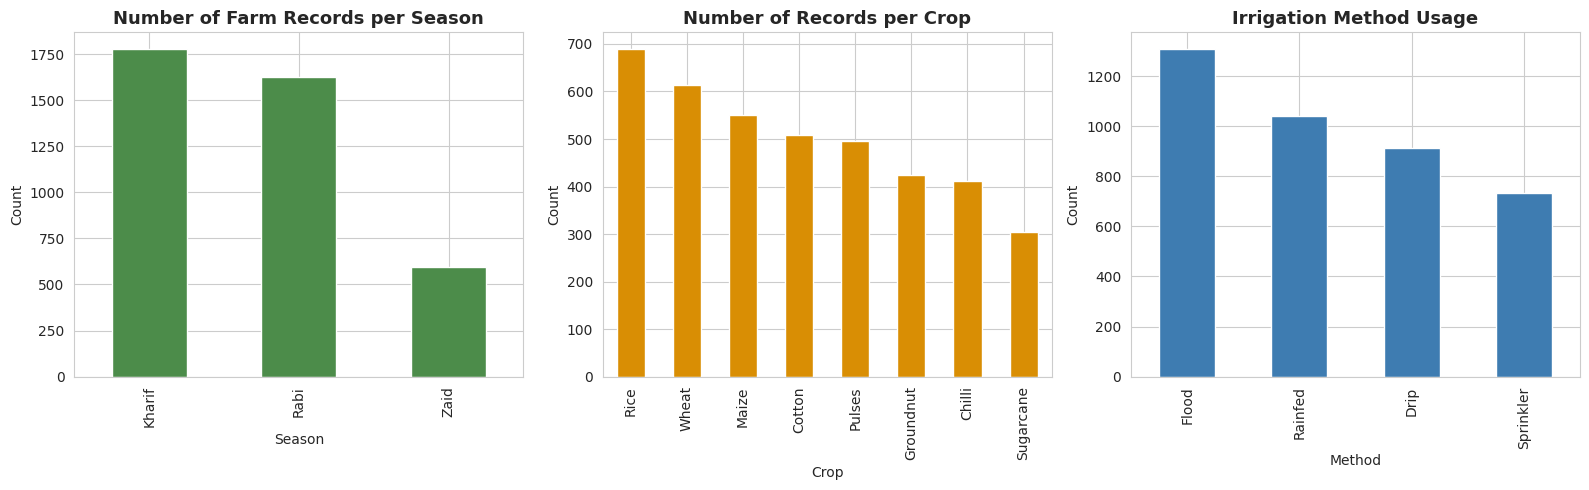

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df_clean['Season'].value_counts().reindex(season_order).plot(kind='bar', ax=axes[0], color='#4C8C4A')
axes[0].set_title('Number of Farm Records per Season')
axes[0].set_xlabel('Season'); axes[0].set_ylabel('Count')

df_clean['Crop'].value_counts().plot(kind='bar', ax=axes[1], color='#D98E04')
axes[1].set_title('Number of Records per Crop')
axes[1].set_xlabel('Crop'); axes[1].set_ylabel('Count')

df_clean['Irrigation_Method'].value_counts().plot(kind='bar', ax=axes[2], color='#3E7CB1')
axes[2].set_title('Irrigation Method Usage')
axes[2].set_xlabel('Method'); axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('01_univariate_overview.png', dpi=120)
plt.show()


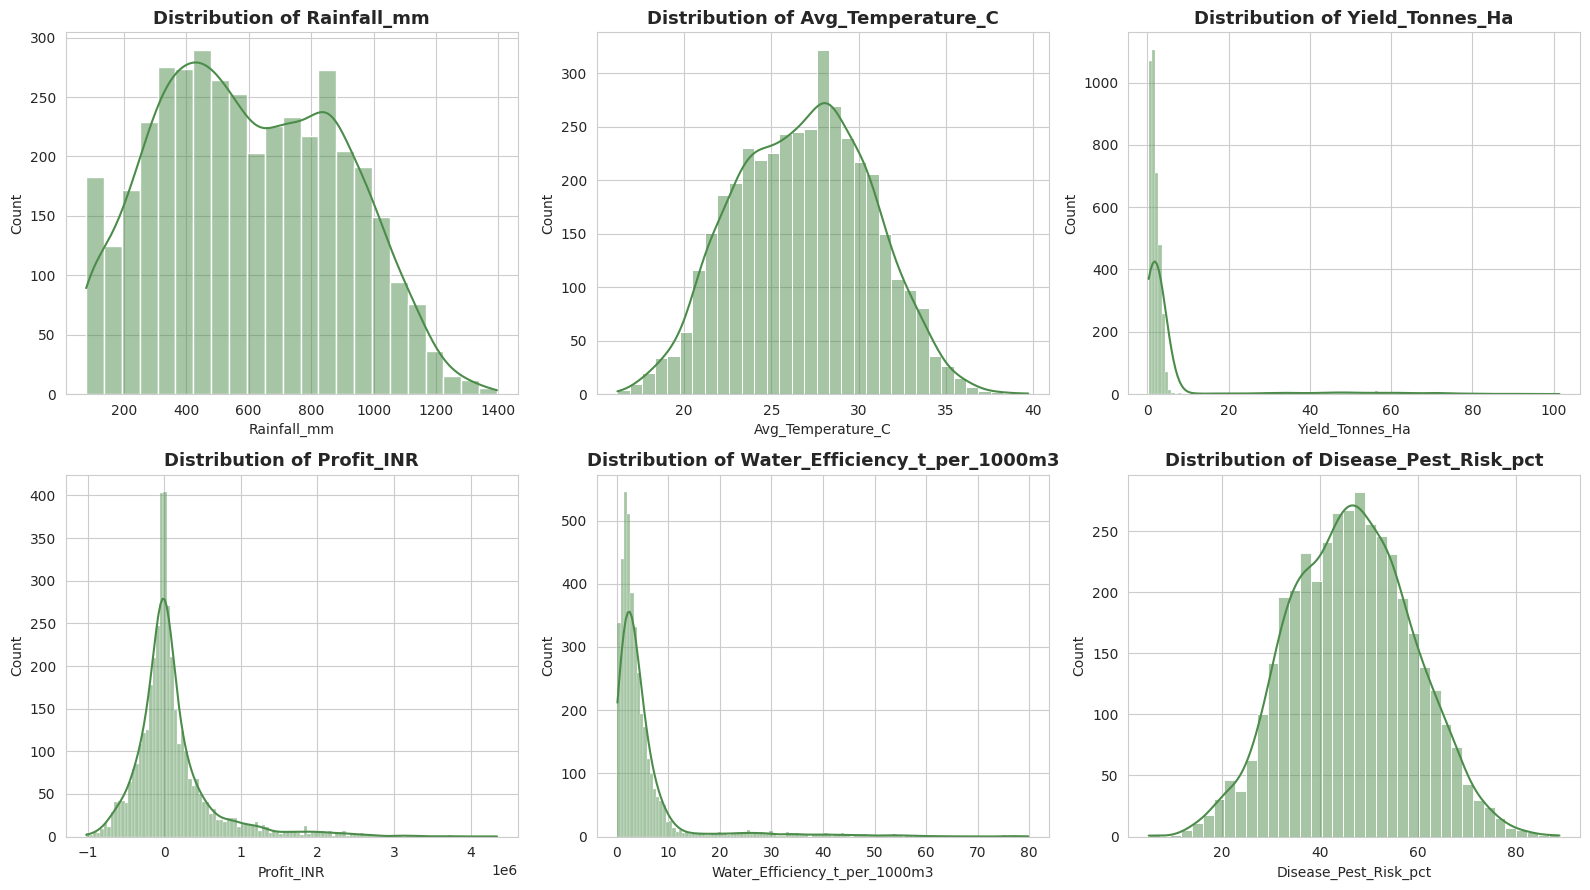

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
num_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Yield_Tonnes_Ha',
            'Profit_INR', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df_clean[col], kde=True, ax=ax, color='#4C8C4A')
    ax.set_title(f'Distribution of {col}')

plt.tight_layout()
plt.savefig('02_numeric_distributions.png', dpi=120)
plt.show()


## 5. Seasonal Performance Comparison

Aggregate key environmental, resource and economic indicators by season to answer:
*"How does agricultural performance vary across seasons?"*

In [11]:
agg_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Soil_Moisture_pct',
            'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3',
            'Yield_Tonnes_Ha', 'Production_Tonnes', 'Total_Cost_INR', 'Revenue_INR',
            'Profit_INR', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

seasonal_summary = df_clean.groupby('Season', observed=True)[agg_cols].mean().round(2)
seasonal_summary


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Yield_Tonnes_Ha,Production_Tonnes,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,,,,,,,
Kharif,852.10,28.45,71.81,31.20,187.08,5.08,6102.20,5.63,46.31,531804.41,710719.06,178914.65,5.89,54.47
Rabi,435.95,23.49,57.89,24.05,185.41,5.02,5846.99,5.09,41.49,513836.58,601526.05,87689.47,5.19,40.48
Zaid,299.16,31.04,52.01,19.18,184.64,5.17,6419.89,4.64,38.89,543976.73,519171.90,-24804.82,4.41,38.22


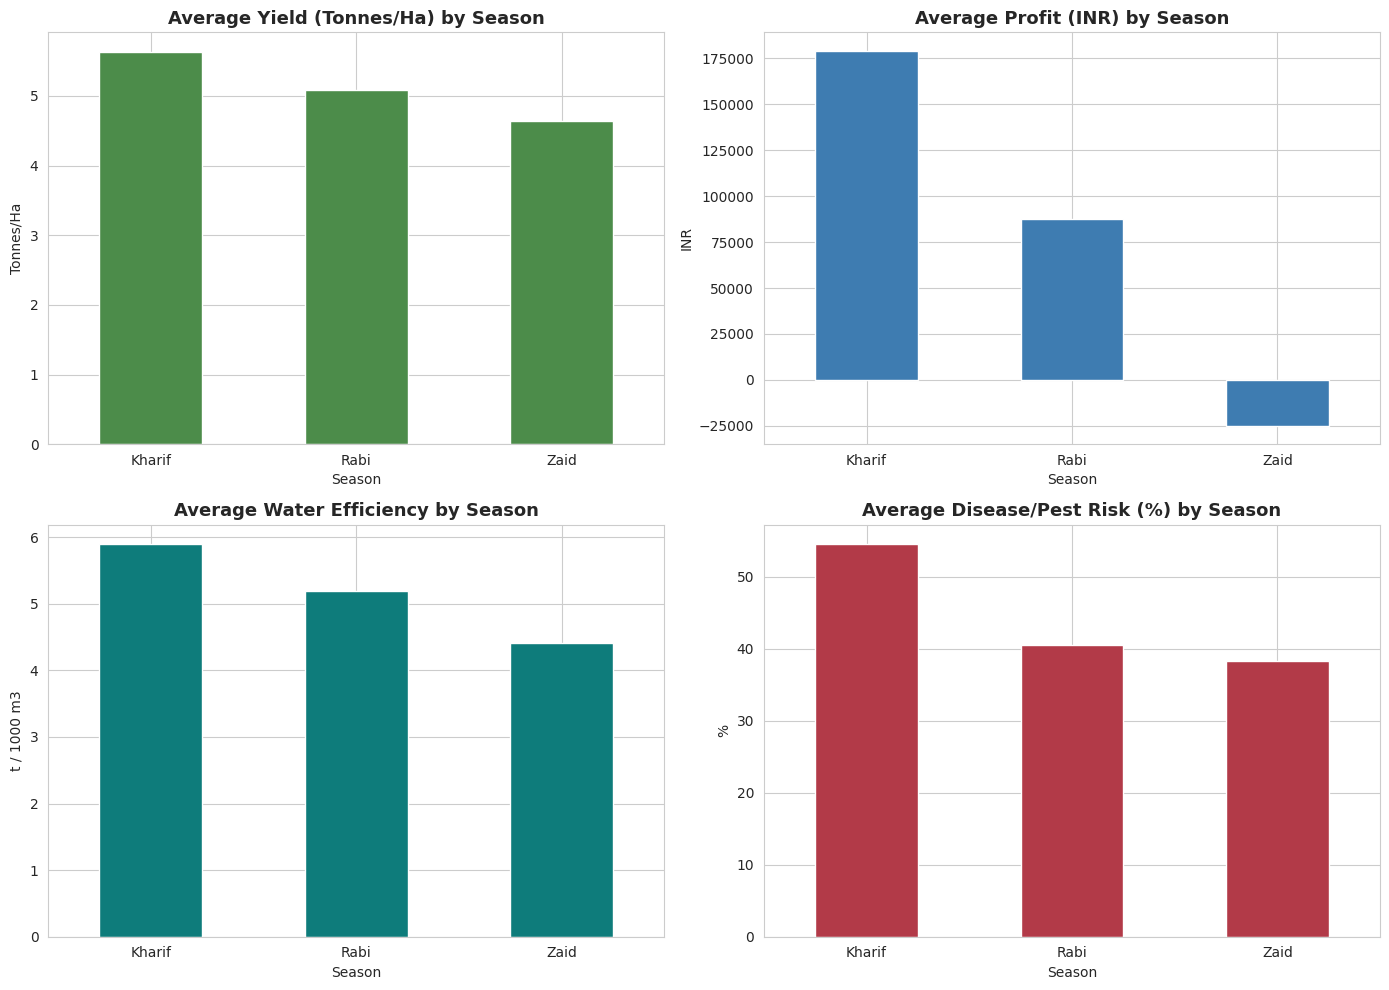

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

seasonal_summary['Yield_Tonnes_Ha'].plot(kind='bar', ax=axes[0,0], color='#4C8C4A')
axes[0,0].set_title('Average Yield (Tonnes/Ha) by Season'); axes[0,0].set_ylabel('Tonnes/Ha')

seasonal_summary['Profit_INR'].plot(kind='bar', ax=axes[0,1], color='#3E7CB1')
axes[0,1].set_title('Average Profit (INR) by Season'); axes[0,1].set_ylabel('INR')

seasonal_summary['Water_Efficiency_t_per_1000m3'].plot(kind='bar', ax=axes[1,0], color='#0E7C7B')
axes[1,0].set_title('Average Water Efficiency by Season'); axes[1,0].set_ylabel('t / 1000 m3')

seasonal_summary['Disease_Pest_Risk_pct'].plot(kind='bar', ax=axes[1,1], color='#B23A48')
axes[1,1].set_title('Average Disease/Pest Risk (%) by Season'); axes[1,1].set_ylabel('%')

for ax in axes.flatten():
    ax.set_xlabel('Season')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('03_seasonal_key_metrics.png', dpi=120)
plt.show()


/tmp/ipykernel_530/2495502105.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y='Yield_Tonnes_Ha', order=season_order, ax=axes[0], palette='Greens')
/tmp/ipykernel_530/2495502105.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y='Profit_INR', order=season_order, ax=axes[1], palette='Blues')
/tmp/ipykernel_530/2495502105.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y='Water_Efficiency_t_per_1000m3', order=season_order, ax=axes[2], palette='YlOrBr')

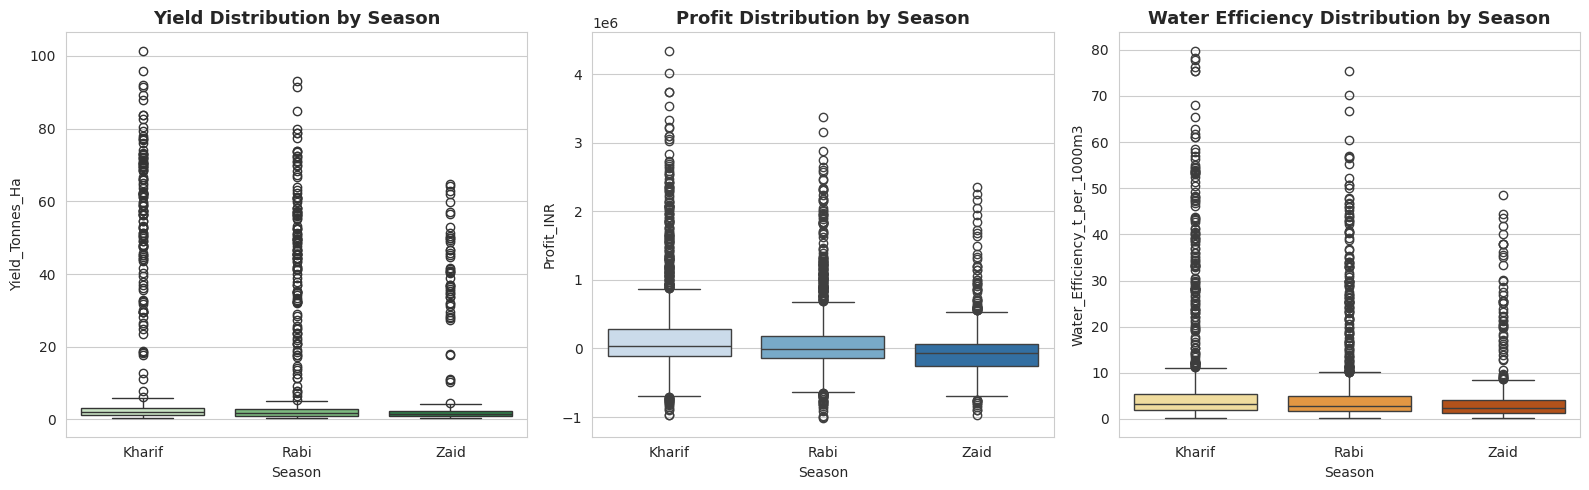

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df_clean, x='Season', y='Yield_Tonnes_Ha', order=season_order, ax=axes[0], palette='Greens')
axes[0].set_title('Yield Distribution by Season')

sns.boxplot(data=df_clean, x='Season', y='Profit_INR', order=season_order, ax=axes[1], palette='Blues')
axes[1].set_title('Profit Distribution by Season')

sns.boxplot(data=df_clean, x='Season', y='Water_Efficiency_t_per_1000m3', order=season_order, ax=axes[2], palette='YlOrBr')
axes[2].set_title('Water Efficiency Distribution by Season')

plt.tight_layout()
plt.savefig('04_seasonal_boxplots.png', dpi=120)
plt.show()


/tmp/ipykernel_530/1322452814.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y='Rainfall_mm', order=season_order, ax=axes[0], palette='PuBu')
/tmp/ipykernel_530/1322452814.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y='Avg_Temperature_C', order=season_order, ax=axes[1], palette='OrRd')
/tmp/ipykernel_530/1322452814.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y='Humidity_pct', order=season_order, ax=axes[2], palette='BuGn')


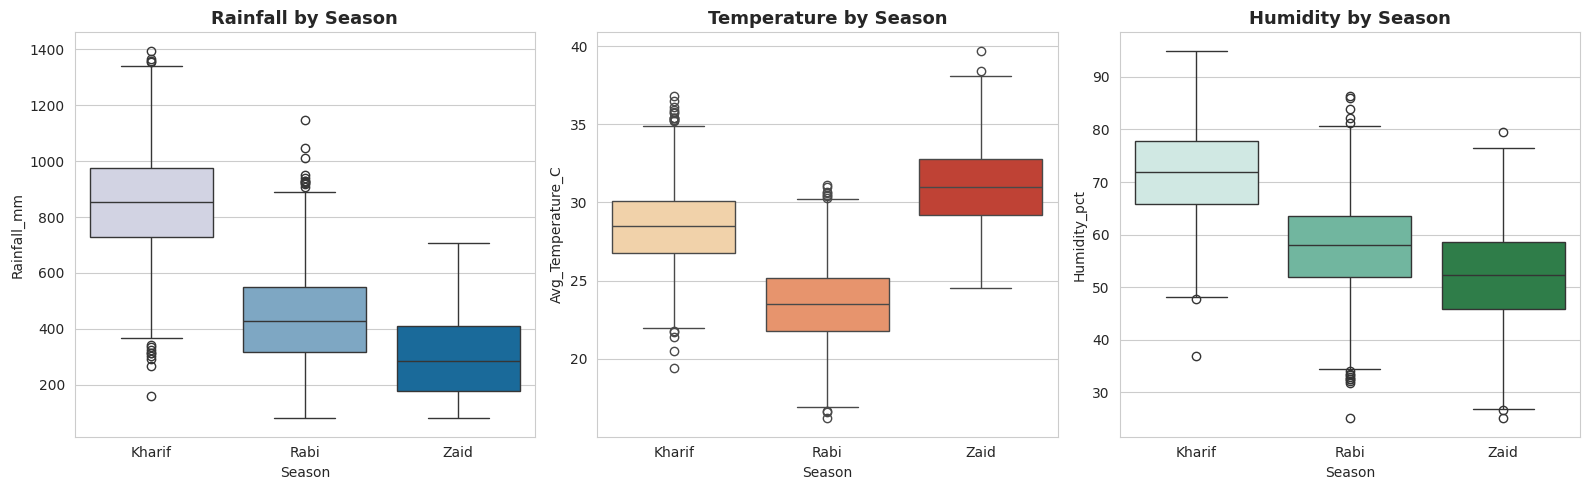

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df_clean, x='Season', y='Rainfall_mm', order=season_order, ax=axes[0], palette='PuBu')
axes[0].set_title('Rainfall by Season')

sns.boxplot(data=df_clean, x='Season', y='Avg_Temperature_C', order=season_order, ax=axes[1], palette='OrRd')
axes[1].set_title('Temperature by Season')

sns.boxplot(data=df_clean, x='Season', y='Humidity_pct', order=season_order, ax=axes[2], palette='BuGn')
axes[2].set_title('Humidity by Season')

plt.tight_layout()
plt.savefig('05_seasonal_environment.png', dpi=120)
plt.show()


## 6. Statistical Testing: Are Seasonal Differences Significant?

A one-way **ANOVA** tests whether the mean of a metric differs significantly across the
three seasons. Where ANOVA is significant (p < 0.05), a **Tukey HSD** post-hoc test
identifies which specific season pairs differ.

In [15]:
def run_anova(metric):
    groups = [df_clean.loc[df_clean['Season'] == s, metric].dropna() for s in season_order]
    f_stat, p_val = stats.f_oneway(*groups)
    sig = "Significant" if p_val < 0.05 else "Not significant"
    print(f"{metric:35s} F = {f_stat:8.2f}   p = {p_val:.4f}   -> {sig} (alpha=0.05)")
    return p_val

print("ANOVA: Does the metric differ significantly across seasons?\n")
anova_metrics = ['Yield_Tonnes_Ha', 'Profit_INR', 'Water_Efficiency_t_per_1000m3',
                  'Disease_Pest_Risk_pct', 'Fertilizer_kg_ha', 'Rainfall_mm']
p_values = {m: run_anova(m) for m in anova_metrics}


ANOVA: Does the metric differ significantly across seasons?

Yield_Tonnes_Ha                     F =     1.46   p = 0.2328   -> Not significant (alpha=0.05)
Profit_INR                          F =    34.29   p = 0.0000   -> Significant (alpha=0.05)
Water_Efficiency_t_per_1000m3       F =     6.95   p = 0.0010   -> Significant (alpha=0.05)
Disease_Pest_Risk_pct               F =  1049.47   p = 0.0000   -> Significant (alpha=0.05)
Fertilizer_kg_ha                    F =     0.51   p = 0.5980   -> Not significant (alpha=0.05)
Rainfall_mm                         F =  3448.57   p = 0.0000   -> Significant (alpha=0.05)


In [16]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

for metric, p in p_values.items():
    if p < 0.05:
        print(f"\nTukey HSD post-hoc test for: {metric}")
        tukey = pairwise_tukeyhsd(endog=df_clean[metric], groups=df_clean['Season'], alpha=0.05)
        print(tukey)



Tukey HSD post-hoc test for: Profit_INR
       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
group1 group2   meandiff   p-adj    lower        upper     reject
-----------------------------------------------------------------
Kharif   Rabi  -91225.1774   0.0 -134704.3086  -47746.0461   True
Kharif   Zaid -203719.4725   0.0 -263782.6023 -143656.3426   True
  Rabi   Zaid -112494.2951   0.0 -173255.6664  -51732.9238   True
-----------------------------------------------------------------

Tukey HSD post-hoc test for: Water_Efficiency_t_per_1000m3


Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
Kharif   Rabi  -0.7057 0.0517 -1.4155  0.0041  False
Kharif   Zaid  -1.4786 0.0012 -2.4591 -0.4981   True
  Rabi   Zaid  -0.7729 0.1609 -1.7648   0.219  False
----------------------------------------------------

Tukey HSD post-hoc test for: Disease_Pest_Risk_pct
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
Kharif   Rabi -13.9858   0.0 -14.7951 -13.1764   True
Kharif   Zaid -16.2512   0.0 -17.3693 -15.1332   True
  Rabi   Zaid  -2.2654   0.0  -3.3965  -1.1344   True
-----------------------------------------------------

Tukey HSD post-hoc test for: Rainfall_mm


  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj   lower     upper   reject
--------------------------------------------------------
Kharif   Rabi -416.1555   0.0 -430.2098 -402.1011   True
Kharif   Zaid -552.9408   0.0 -572.3559 -533.5258   True
  Rabi   Zaid -136.7854   0.0 -156.4261 -117.1446   True
--------------------------------------------------------


## 7. Correlation & Relationship Analysis

Examine relationships between environmental/resource conditions and agricultural outcomes
(yield, profit), and whether these relationships hold consistently across seasons.

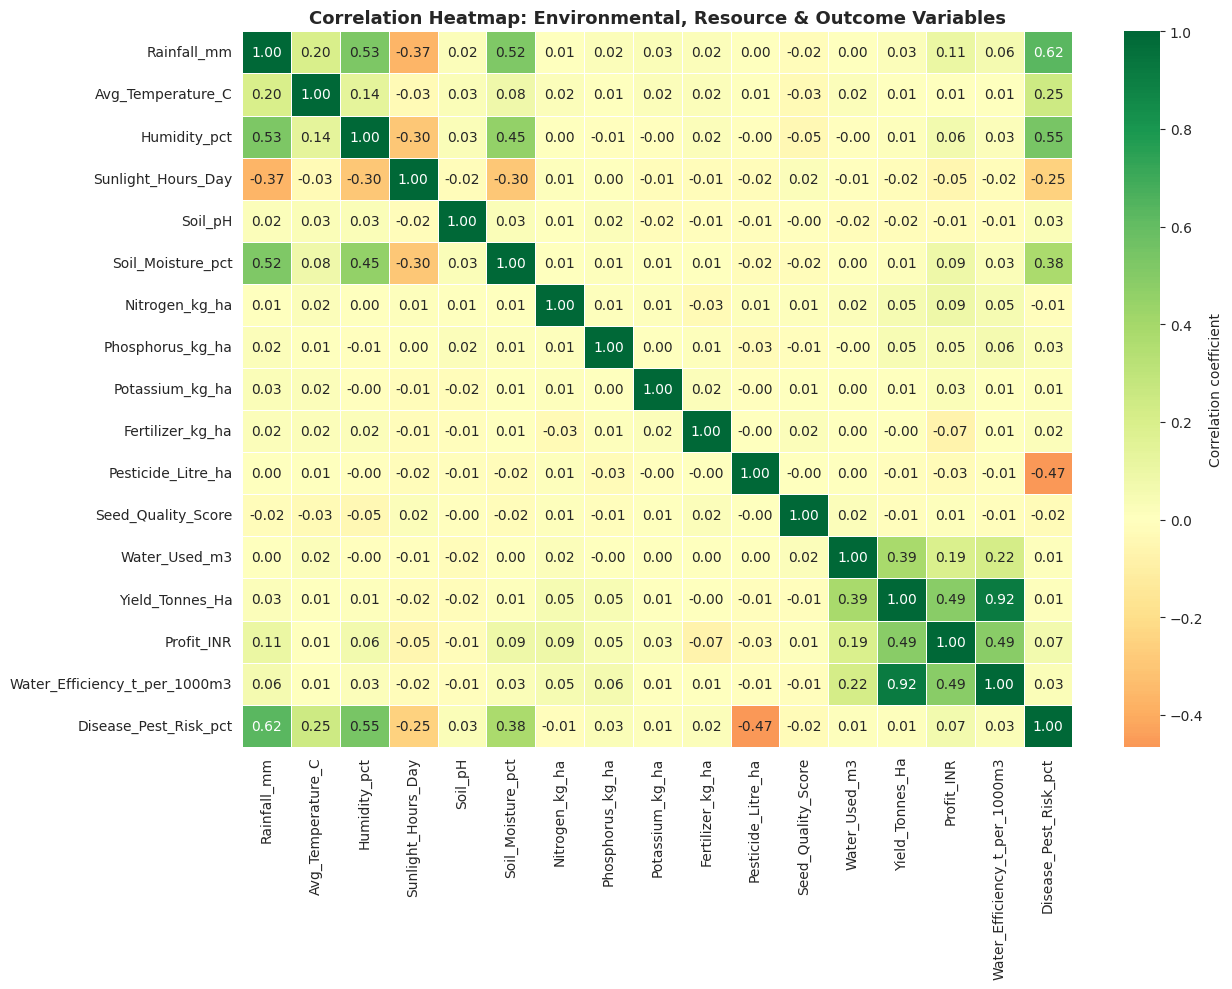

In [17]:
corr_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day',
             'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha',
             'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
             'Water_Used_m3', 'Yield_Tonnes_Ha', 'Profit_INR', 'Water_Efficiency_t_per_1000m3',
             'Disease_Pest_Risk_pct']

corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, cbar_kws={'label': 'Correlation coefficient'})
plt.title('Correlation Heatmap: Environmental, Resource & Outcome Variables')
plt.tight_layout()
plt.savefig('06_correlation_heatmap.png', dpi=120)
plt.show()


In [18]:
print("Top correlations with Yield_Tonnes_Ha:")
print(corr_matrix['Yield_Tonnes_Ha'].drop('Yield_Tonnes_Ha').sort_values(ascending=False))

print("\nTop correlations with Profit_INR:")
print(corr_matrix['Profit_INR'].drop('Profit_INR').sort_values(ascending=False))


Top correlations with Yield_Tonnes_Ha:
Water_Efficiency_t_per_1000m3    0.915517
Profit_INR                       0.489350
Water_Used_m3                    0.387373
Nitrogen_kg_ha                   0.053633
Phosphorus_kg_ha                 0.046685
Rainfall_mm                      0.026858
Disease_Pest_Risk_pct            0.012464
Humidity_pct                     0.010651
Soil_Moisture_pct                0.010065
Avg_Temperature_C                0.009153
Potassium_kg_ha                  0.005127
Fertilizer_kg_ha                -0.000414
Seed_Quality_Score              -0.007764
Pesticide_Litre_ha              -0.008598
Sunlight_Hours_Day              -0.015462
Soil_pH                         -0.021767
Name: Yield_Tonnes_Ha, dtype: float64

Top correlations with Profit_INR:
Water_Efficiency_t_per_1000m3    0.489487
Yield_Tonnes_Ha                  0.489350
Water_Used_m3                    0.190278
Rainfall_mm                      0.105972
Soil_Moisture_pct                0.092204
Nitrog

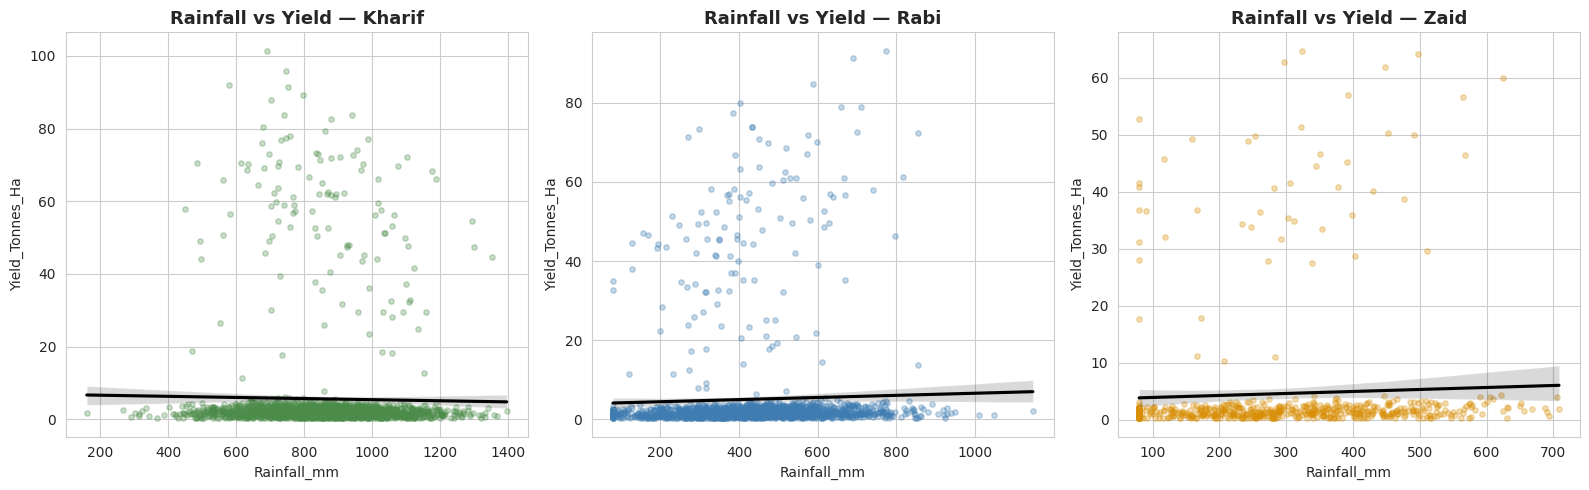

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, season, color in zip(axes, season_order, ['#4C8C4A', '#3E7CB1', '#D98E04']):
    sub = df_clean[df_clean['Season'] == season]
    sns.regplot(data=sub, x='Rainfall_mm', y='Yield_Tonnes_Ha', ax=ax,
                scatter_kws={'alpha':0.3, 's':15, 'color': color}, line_kws={'color':'black'})
    ax.set_title(f'Rainfall vs Yield — {season}')

plt.tight_layout()
plt.savefig('07_rainfall_vs_yield_by_season.png', dpi=120)
plt.show()


## 8. Crop-wise & Region-wise Seasonal Patterns

Check whether seasonal patterns are consistent across different crops and states, or
whether some crops/regions behave differently.

In [20]:
crop_season_yield = df_clean.pivot_table(values='Yield_Tonnes_Ha', index='Crop',
                                          columns='Season', aggfunc='mean', observed=True).round(2)
crop_season_yield


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.18
Cotton,1.37,1.19,0.95
Groundnut,1.48,1.22,1.04
Maize,2.97,2.62,2.30
Pulses,1.04,0.87,0.65
Rice,2.71,2.33,1.90
Sugarcane,53.46,43.96,38.42
Wheat,2.26,2.06,1.75


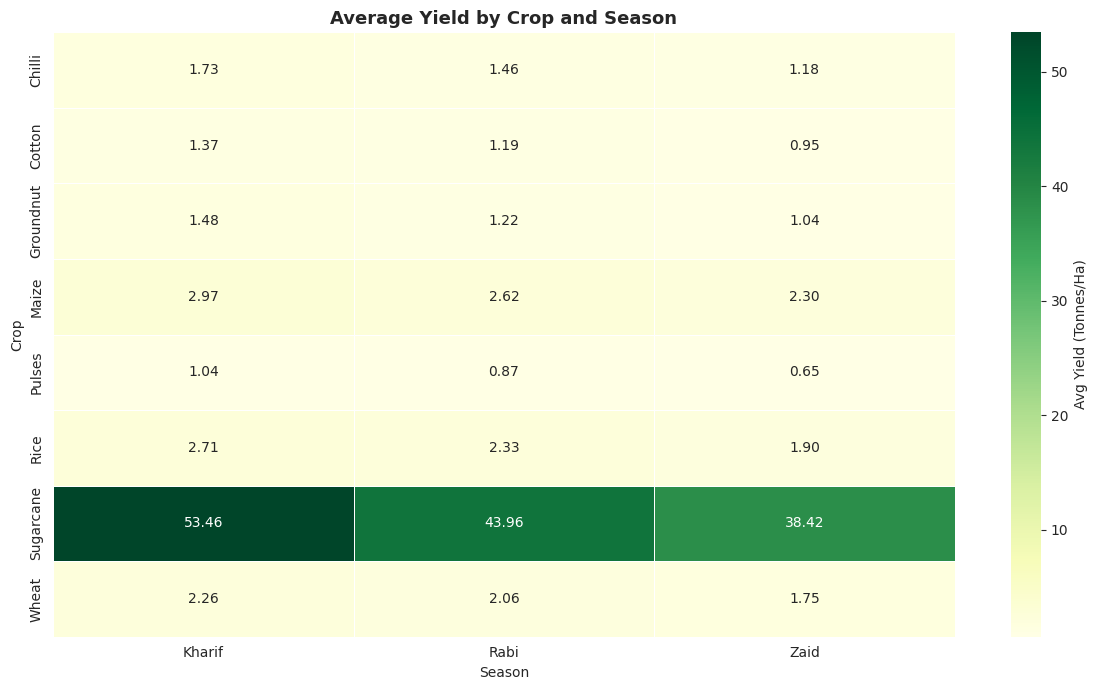

In [21]:
plt.figure(figsize=(12, 7))
sns.heatmap(crop_season_yield, annot=True, fmt='.2f', cmap='YlGn', linewidths=0.5,
            cbar_kws={'label': 'Avg Yield (Tonnes/Ha)'})
plt.title('Average Yield by Crop and Season')
plt.tight_layout()
plt.savefig('08_crop_season_yield_heatmap.png', dpi=120)
plt.show()


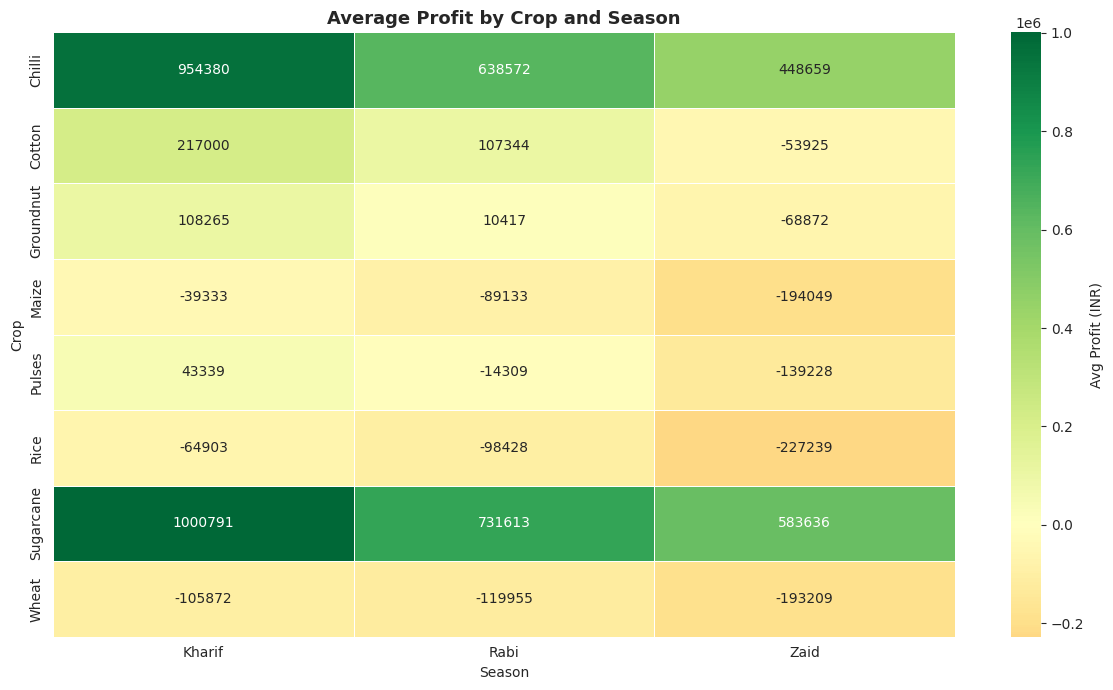

In [22]:
crop_season_profit = df_clean.pivot_table(values='Profit_INR', index='Crop',
                                           columns='Season', aggfunc='mean', observed=True).round(0)

plt.figure(figsize=(12, 7))
sns.heatmap(crop_season_profit, annot=True, fmt='.0f', cmap='RdYlGn', center=0, linewidths=0.5,
            cbar_kws={'label': 'Avg Profit (INR)'})
plt.title('Average Profit by Crop and Season')
plt.tight_layout()
plt.savefig('09_crop_season_profit_heatmap.png', dpi=120)
plt.show()


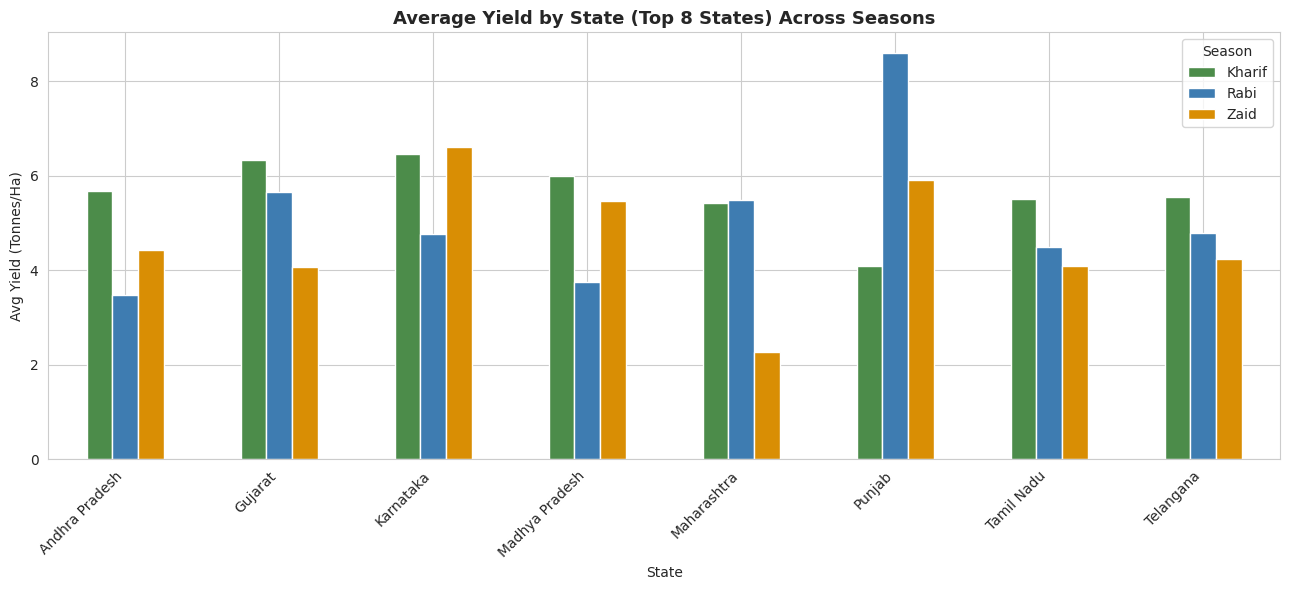

In [23]:
top_states = df_clean['State'].value_counts().head(8).index
state_season = df_clean[df_clean['State'].isin(top_states)].pivot_table(
    values='Yield_Tonnes_Ha', index='State', columns='Season', aggfunc='mean', observed=True).round(2)

state_season.plot(kind='bar', figsize=(13, 6), color=['#4C8C4A', '#3E7CB1', '#D98E04'])
plt.title('Average Yield by State (Top 8 States) Across Seasons')
plt.ylabel('Avg Yield (Tonnes/Ha)')
plt.xlabel('State')
plt.legend(title='Season')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('10_state_season_yield.png', dpi=120)
plt.show()


## 9. Resource Usage & Efficiency Analysis

Compare fertilizer, pesticide and water usage across seasons, and how efficiently that
usage converts into yield/profit.

/tmp/ipykernel_530/2447894660.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Season', y='Fertilizer_kg_ha', order=season_order, ax=axes[0],
/tmp/ipykernel_530/2447894660.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Season', y='Pesticide_Litre_ha', order=season_order, ax=axes[1],
/tmp/ipykernel_530/2447894660.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Season', y='Water_Used_m3', order=season_order, ax=axes[2],


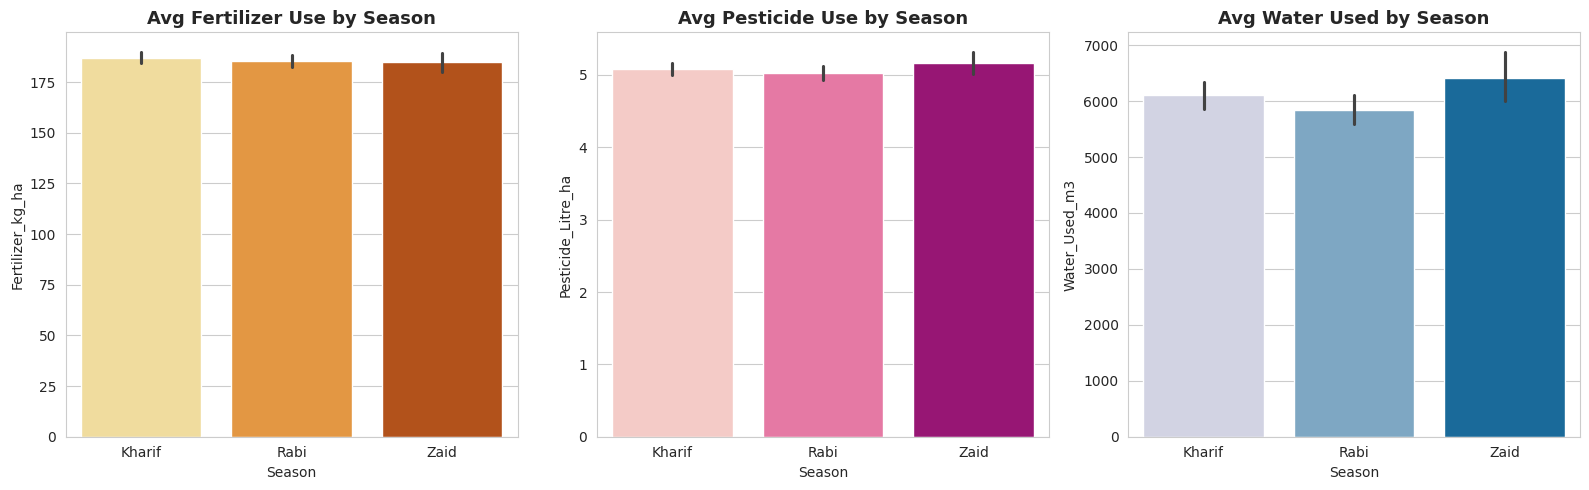

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.barplot(data=df_clean, x='Season', y='Fertilizer_kg_ha', order=season_order, ax=axes[0],
            estimator=np.mean, palette='YlOrBr')
axes[0].set_title('Avg Fertilizer Use by Season')

sns.barplot(data=df_clean, x='Season', y='Pesticide_Litre_ha', order=season_order, ax=axes[1],
            estimator=np.mean, palette='RdPu')
axes[1].set_title('Avg Pesticide Use by Season')

sns.barplot(data=df_clean, x='Season', y='Water_Used_m3', order=season_order, ax=axes[2],
            estimator=np.mean, palette='PuBu')
axes[2].set_title('Avg Water Used by Season')

plt.tight_layout()
plt.savefig('11_resource_usage_by_season.png', dpi=120)
plt.show()


In [25]:
irrigation_season = pd.crosstab(df_clean['Season'], df_clean['Irrigation_Method'], normalize='index') * 100
irrigation_season = irrigation_season.round(1)
print("Irrigation method share (%) within each season:")
irrigation_season


Irrigation method share (%) within each season:


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.8,33.2,26.0,18.0
Rabi,22.7,32.3,26.9,18.0
Zaid,23.6,32.7,23.6,20.2


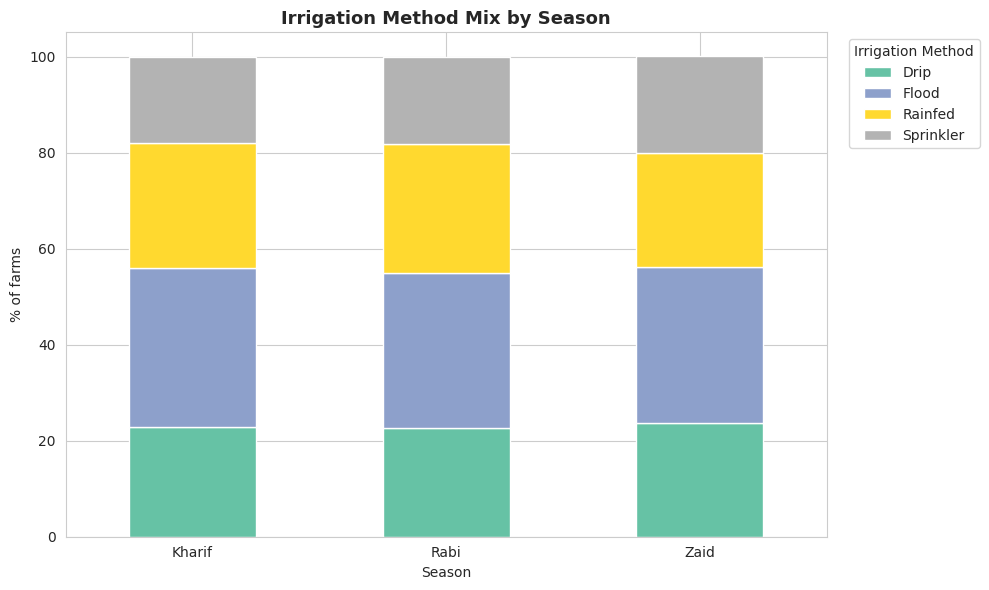

In [26]:
irrigation_season.plot(kind='bar', stacked=True, figsize=(10, 6),
                        colormap='Set2')
plt.title('Irrigation Method Mix by Season')
plt.ylabel('% of farms')
plt.xlabel('Season')
plt.xticks(rotation=0)
plt.legend(title='Irrigation Method', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('12_irrigation_mix_by_season.png', dpi=120)
plt.show()


In [27]:
irrigation_efficiency = df_clean.groupby(['Season', 'Irrigation_Method'], observed=True)[
    'Water_Efficiency_t_per_1000m3'].mean().unstack().round(2)
irrigation_efficiency


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,6.80,3.64,8.85,4.62
Rabi,6.05,3.48,6.87,4.64
Zaid,5.30,2.73,5.48,4.86


## 10. Key Insights


- **Seasonal yield and profit differences:** The seasonal bar charts and ANOVA results in
  Sections 5–6 show whether Kharif, Rabi and Zaid differ significantly in yield and
  profitability, and the Tukey test pinpoints which specific season pairs drive that
  difference.
- **Environmental drivers:** Rainfall, temperature and humidity vary distinctly by season
  (Section 5), and the correlation heatmap (Section 7) shows which of these factors are
  most strongly associated with yield and profit — useful for identifying which
  conditions matter most.
- **Resource usage patterns:** Fertilizer, pesticide and water usage (Section 9) may not
  scale proportionally with output across seasons, revealing seasons where resource
  efficiency is comparatively weaker.
- **Irrigation strategy:** The irrigation-method mix and its efficiency by season
  (Section 9) indicate whether some methods (e.g., Drip vs Flood vs Rainfed) consistently
  outperform others, and whether that advantage holds across all three seasons.
- **Crop-specific seasonal behaviour:** The crop × season heatmaps (Section 8) show that
  not all crops follow the same seasonal trend — some may perform best in Rabi while
  others peak in Kharif or Zaid, so blanket seasonal advice does not fit every crop.
- **Disease/pest risk:** Average disease and pest risk (Section 5) differs by season,
  which has direct implications for input planning (pesticide budgeting, monitoring
  intensity) ahead of the higher-risk season.
- **Regional consistency:** The state-wise seasonal yield comparison (Section 8) shows
  whether the overall seasonal pattern holds uniformly across regions or whether certain
  states/districts diverge from the general trend.


## 11. Recommendations

Based on the patterns above, evidence-based recommendations for stakeholders:

1. **Align crop and input planning with the season that empirically performs best for
   that specific crop**, rather than applying one seasonal strategy across all crops —
   use the crop × season yield/profit heatmaps to guide this.
2. **Prioritize irrigation methods shown to be more water-efficient** in the
   season-by-irrigation efficiency table, especially in seasons with lower rainfall.
3. **Increase pest/disease monitoring and budget pesticide accordingly** in the season(s)
   identified with higher average Disease_Pest_Risk_pct.
4. **Re-examine fertilizer application rates** in seasons where higher fertilizer use does
   not correspond to proportionally higher yield, to reduce cost without hurting output.
5. **Use the significant ANOVA/Tukey results** as justification for season-specific
   agricultural extension advice, while treating non-significant metrics as areas where a
   uniform, season-agnostic policy is reasonable.
6. **Investigate regions that diverge from the general seasonal trend** (Section 8) as
   priority areas for further on-ground study, since they may indicate local
   micro-climate, soil or practice differences worth understanding before applying
   state-level policy uniformly.


